In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator

RUNS_DIR = Path("..") / "runs"

DEEPLAB_RUN = "20260424_060156_deeplabv3plus_bs8_lr1e-03_focal"
UNET_RUN = "20260424_140420_unet_bs8_lr1e-03_focal"
FCN_RUN = "20260426_190455_fcn8s_bs8_lr1e-03_focal"

for run in (DEEPLAB_RUN, UNET_RUN, FCN_RUN):
    assert (RUNS_DIR / run).is_dir(), f"missing run: {RUNS_DIR / run}"
print("Found all runs under", RUNS_DIR.resolve())

Found all runs under C:\Users\user\Documents\Python Scripts\cityscape_seg\runs


In [2]:
def read_scalar(run_dir: Path, main_tag: str, sub_tag: str) -> pd.DataFrame:
    """Read a scalar curve logged via ``writer.add_scalars(main_tag, {sub_tag: ...}, step)``.

    TensorBoard stores it under ``run_dir/<main_tag>_<sub_tag>/events...`` with tag ``main_tag``.
    Returns a DataFrame with columns ``step`` and ``value``.
    """
    sub_dir = run_dir / f"{main_tag}_{sub_tag}"
    if not sub_dir.is_dir():
        raise FileNotFoundError(f"No sub-run dir at {sub_dir}")
    ea = EventAccumulator(str(sub_dir), size_guidance={"scalars": 0})
    ea.Reload()
    if main_tag not in ea.Tags()["scalars"]:
        raise KeyError(
            f"Tag '{main_tag}' not found in {sub_dir}. Available: {ea.Tags()['scalars']}"
        )
    events = ea.Scalars(main_tag)
    return pd.DataFrame({"step": [e.step for e in events], "value": [e.value for e in events]})


def load_run(run_dir: Path) -> dict[str, pd.DataFrame]:
    """Return a dict of dataframes keyed by ``Loss/train``, ``Loss/val``, ``Accuracy/train``, ``Accuracy/val``."""
    return {
        "Loss/train": read_scalar(run_dir, "Loss", "train"),
        "Loss/val": read_scalar(run_dir, "Loss", "val"),
        "Accuracy/train": read_scalar(run_dir, "Accuracy", "train"),
        "Accuracy/val": read_scalar(run_dir, "Accuracy", "val"),
    }

In [3]:
deeplab = load_run(RUNS_DIR / DEEPLAB_RUN)
unet = load_run(RUNS_DIR / UNET_RUN)
fcn = load_run(RUNS_DIR / FCN_RUN)

for name, run in [("FCN-8s", fcn), ("U-Net", unet), ("DeepLabV3+", deeplab)]:
    print(f"\n{name}")
    for k, df in run.items():
        print(f"  {k:<16s}  {len(df):>3d} epochs  last={df['value'].iloc[-1]:.4f}")


FCN-8s
  Loss/train         98 epochs  last=0.1461
  Loss/val           98 epochs  last=0.2148
  Accuracy/train     98 epochs  last=0.9216
  Accuracy/val       98 epochs  last=0.8864

U-Net
  Loss/train         60 epochs  last=0.1245
  Loss/val           60 epochs  last=0.1874
  Accuracy/train     60 epochs  last=0.9296
  Accuracy/val       60 epochs  last=0.8978

DeepLabV3+
  Loss/train         73 epochs  last=0.1107
  Loss/val           73 epochs  last=0.1807
  Accuracy/train     73 epochs  last=0.9378
  Accuracy/val       73 epochs  last=0.9058


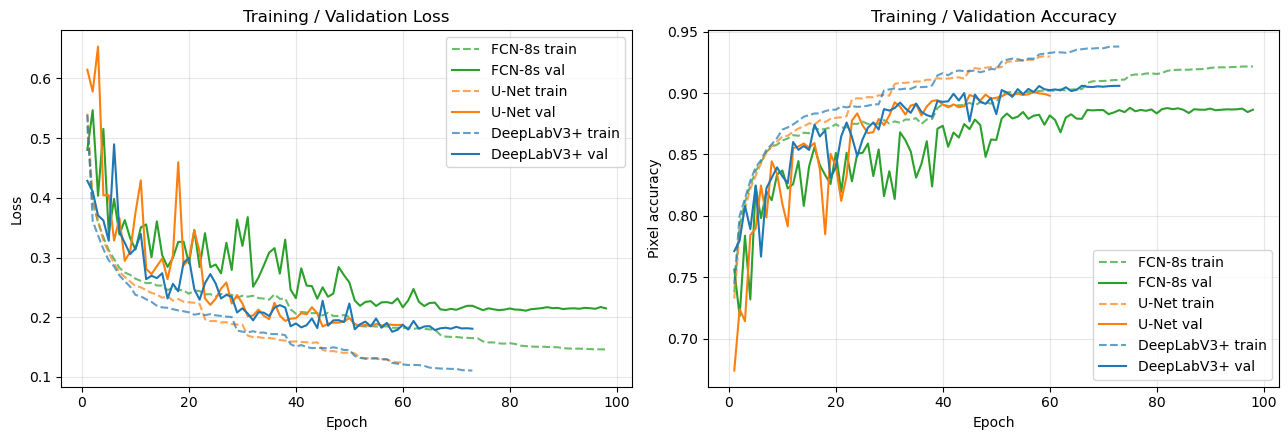

In [4]:
fig, (ax_loss, ax_acc) = plt.subplots(1, 2, figsize=(13, 4.5))

for label, run, color in [
    ("FCN-8s", fcn, "C2"),
    ("U-Net", unet, "C1"),
    ("DeepLabV3+", deeplab, "C0"),
]:
    ax_loss.plot(
        run["Loss/train"]["step"],
        run["Loss/train"]["value"],
        color=color,
        linestyle="--",
        alpha=0.7,
        label=f"{label} train",
    )
    ax_loss.plot(
        run["Loss/val"]["step"],
        run["Loss/val"]["value"],
        color=color,
        linestyle="-",
        label=f"{label} val",
    )

    ax_acc.plot(
        run["Accuracy/train"]["step"],
        run["Accuracy/train"]["value"],
        color=color,
        linestyle="--",
        alpha=0.7,
        label=f"{label} train",
    )
    ax_acc.plot(
        run["Accuracy/val"]["step"],
        run["Accuracy/val"]["value"],
        color=color,
        linestyle="-",
        label=f"{label} val",
    )

ax_loss.set_xlabel("Epoch")
ax_loss.set_ylabel("Loss")
ax_loss.set_title("Training / Validation Loss")
ax_loss.legend()
ax_loss.grid(alpha=0.3)

ax_acc.set_xlabel("Epoch")
ax_acc.set_ylabel("Pixel accuracy")
ax_acc.set_title("Training / Validation Accuracy")
ax_acc.legend()
ax_acc.grid(alpha=0.3)

plt.tight_layout()
plt.show()

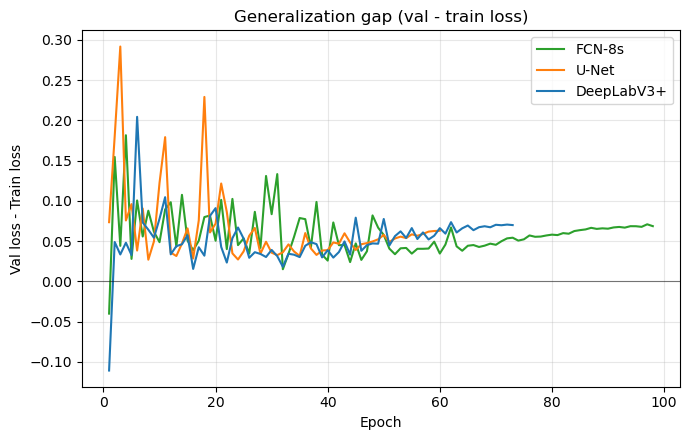

In [5]:
fig, ax = plt.subplots(figsize=(7, 4.5))

for label, run, color in [
    ("FCN-8s", fcn, "C2"),
    ("U-Net", unet, "C1"),
    ("DeepLabV3+", deeplab, "C0"),
]:
    train = run["Loss/train"].set_index("step")["value"]
    val = run["Loss/val"].set_index("step")["value"]
    gap = (val - train).dropna()
    ax.plot(gap.index, gap.values, color=color, label=label)

ax.axhline(0, color="black", linewidth=0.8, alpha=0.5)
ax.set_xlabel("Epoch")
ax.set_ylabel("Val loss - Train loss")
ax.set_title("Generalization gap (val - train loss)")
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()